In [52]:
from google.colab import files
uploaded = files.upload()

Saving customer_support_tickets.csv to customer_support_tickets (2).csv


In [53]:
import pandas as pd
import numpy as np
import re
import nltk

from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## **Download Stopwords**

In [54]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## **Load the Dataset**

In [55]:
df = pd.read_csv("customer_support_tickets.csv")

df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [56]:
df.columns

Index(['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age',
       'Customer Gender', 'Product Purchased', 'Date of Purchase',
       'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status',
       'Resolution', 'Ticket Priority', 'Ticket Channel',
       'First Response Time', 'Time to Resolution',
       'Customer Satisfaction Rating'],
      dtype='object')

## **Combine Text Columns**

In [57]:
df["text"] = df["Ticket Subject"] + " " + df["Ticket Description"]

df = df[["text","Ticket Type","Ticket Priority"]]

df.head()

,text,Ticket Type,Ticket Priority
0,Product setup I'm having an issue with the {pr...,Technical issue,Critical
1,Peripheral compatibility I'm having an issue w...,Technical issue,Critical
2,Network problem I'm facing a problem with my {...,Technical issue,Low
3,Account access I'm having an issue with the {p...,Billing inquiry,Low
4,Data loss I'm having an issue with the {produc...,Billing inquiry,Low


## **Text Cleaning**

In [58]:
def clean_text(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    words = text.split()

    words = [w for w in words if w not in stop_words]

    return " ".join(words)

df["clean_text"] = df["text"].apply(clean_text)

df.head()

,text,Ticket Type,Ticket Priority,clean_text
0,Product setup I'm having an issue with the {pr...,Technical issue,Critical,product setup im issue productpurchased please...
1,Peripheral compatibility I'm having an issue w...,Technical issue,Critical,peripheral compatibility im issue productpurch...
2,Network problem I'm facing a problem with my {...,Technical issue,Low,network problem im facing problem productpurch...
3,Account access I'm having an issue with the {p...,Billing inquiry,Low,account access im issue productpurchased pleas...
4,Data loss I'm having an issue with the {produc...,Billing inquiry,Low,data loss im issue productpurchased please ass...


## **Feature Extraction (TF-IDF)**

In [59]:
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df["clean_text"])

In [60]:
y_category = df["Ticket Type"]
y_priority = df["Ticket Priority"]

In [61]:
df["Ticket Type"] = df["Ticket Type"].str.strip()
df["Ticket Priority"] = df["Ticket Priority"].str.strip()

## **Train Test Split**

In [62]:
X_train, X_test, y_train_cat, y_test_cat = train_test_split(
    X, y_category, test_size=0.2, random_state=42)

X_train2, X_test2, y_train_pri, y_test_pri = train_test_split(
    X, y_priority, test_size=0.2, random_state=42)

## **Train Category Classification Model**

In [63]:
category_model = LogisticRegression(max_iter=1000)

category_model.fit(X_train, y_train_cat)

pred_cat = category_model.predict(X_test)

## **Evaluate Category Model**

In [64]:
print("Category Accuracy:", accuracy_score(y_test_cat, pred_cat))

print(classification_report(y_test_cat, pred_cat))

Category Accuracy: 0.19008264462809918
                      precision    recall  f1-score   support

     Billing inquiry       0.18      0.13      0.15       357
Cancellation request       0.17      0.18      0.17       327
     Product inquiry       0.19      0.19      0.19       316
      Refund request       0.19      0.21      0.20       345
     Technical issue       0.22      0.24      0.23       349

            accuracy                           0.19      1694
           macro avg       0.19      0.19      0.19      1694
        weighted avg       0.19      0.19      0.19      1694



## **Confusion Matrix for Category Prediction**

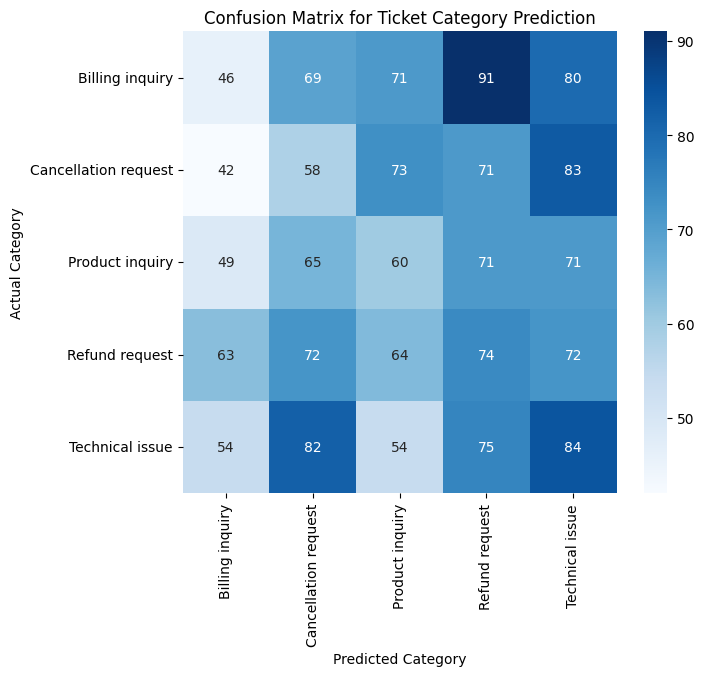

In [76]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Create confusion matrix
cm_category = confusion_matrix(y_test_cat, pred_cat)

# Get category labels
category_labels = category_model.classes_

# Plot confusion matrix
plt.figure(figsize=(7,6))

sns.heatmap(cm_category,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=category_labels,
            yticklabels=category_labels)

plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")
plt.title("Confusion Matrix for Ticket Category Prediction")

plt.show()

## **Train Priority Prediction Model**

In [67]:
priority_model = LogisticRegression(max_iter=1000)

priority_model.fit(X_train2, y_train_pri)

pred_pri = priority_model.predict(X_test2)

## **Evaluate Priority Model**

In [68]:
print("Priority Accuracy:", accuracy_score(y_test_pri, pred_pri))

print(classification_report(y_test_pri, pred_pri))

Priority Accuracy: 0.2680047225501771
              precision    recall  f1-score   support

    Critical       0.27      0.29      0.28       411
        High       0.26      0.27      0.27       409
         Low       0.25      0.24      0.24       415
      Medium       0.28      0.27      0.28       459

    accuracy                           0.27      1694
   macro avg       0.27      0.27      0.27      1694
weighted avg       0.27      0.27      0.27      1694



## **Test Model with Custom Ticket**

In [69]:
sample = ["my payment was deducted but order not confirmed"]

sample_clean = [clean_text(s) for s in sample]

sample_vec = tfidf.transform(sample_clean)

print("Predicted Category:", category_model.predict(sample_vec))
print("Predicted Priority:", priority_model.predict(sample_vec))

Predicted Category: ['Refund request']
Predicted Priority: ['Medium']


## **Confusion Matrix for Priority Prediction**

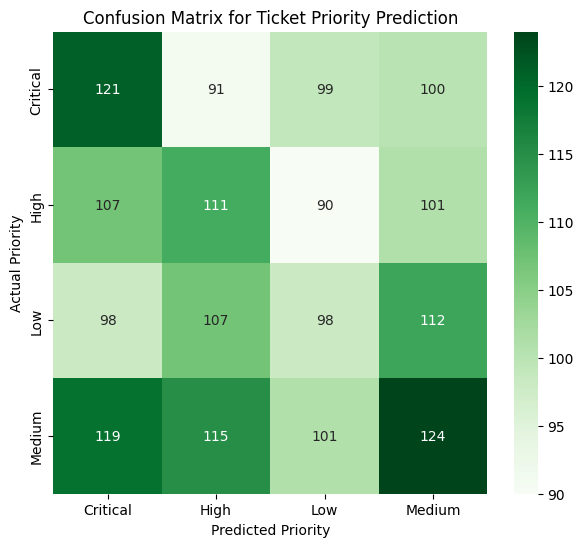

In [77]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Create confusion matrix
cm_priority = confusion_matrix(y_test_pri, pred_pri)

# Get priority labels
priority_labels = priority_model.classes_

# Plot confusion matrix
plt.figure(figsize=(7,6))

sns.heatmap(cm_priority,
            annot=True,
            fmt='d',
            cmap='Greens',
            xticklabels=priority_labels,
            yticklabels=priority_labels)

plt.xlabel("Predicted Priority")
plt.ylabel("Actual Priority")
plt.title("Confusion Matrix for Ticket Priority Prediction")

plt.show()